**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style('whitegrid')
%matplotlib inline

**Loading Dataset**

In [2]:
df = pd.read_csv("data\PRSA_data.csv") 
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [3]:
df['Datetime'] = pd.to_datetime(df[['year','month','day','hour']])
df = df.sort_values("Datetime").reset_index(drop = True)
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,Datetime
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00


**Dataset Overview**

In [4]:
print("Shape:",df.shape)        
print('\n column dtypes :',df.dtypes)
print('\n Date range :', df['Datetime'].min(),'-',df['Datetime'].max())
print("Duplicated timestamp:",df['Datetime'].duplicated().sum())
print('\n wind direction (cbwd) categories:')
print(df['cbwd'].value_counts())


Shape: (43824, 14)

 column dtypes : No                   int64
year                 int64
month                int64
day                  int64
hour                 int64
pm2.5              float64
DEWP                 int64
TEMP               float64
PRES               float64
cbwd                   str
Iws                float64
Is                   int64
Ir                   int64
Datetime    datetime64[us]
dtype: object

 Date range : 2010-01-01 00:00:00 - 2014-12-31 23:00:00
Duplicated timestamp: 0

 wind direction (cbwd) categories:
cbwd
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64


**Missing Values**

In [5]:
df.isna().sum()
df['pm2.5'] = df['pm2.5'].fillna(df['pm2.5'].mean())


**Target variable Distribution**

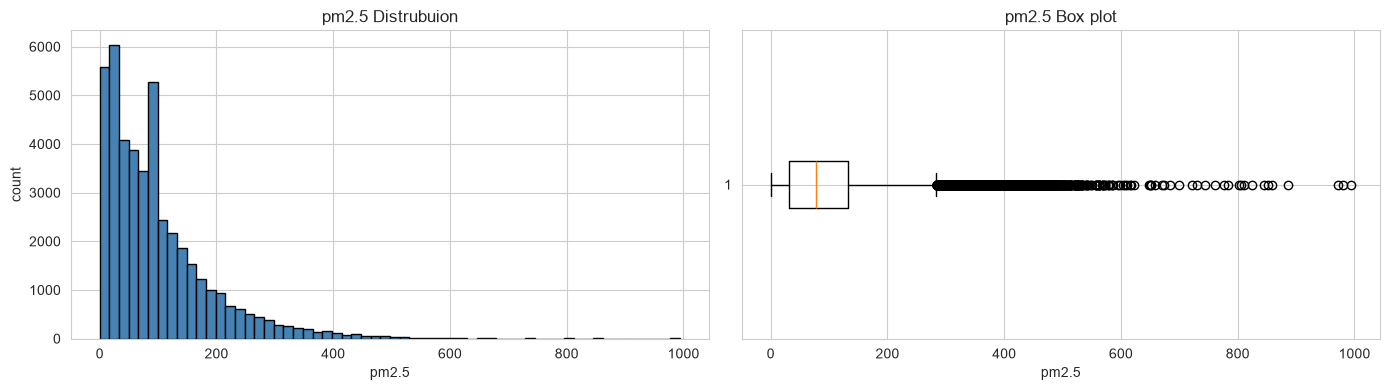

Skewness 1.85


In [6]:
fig,axes = plt.subplots(1,2,figsize = (14,4))   
axes[0].hist(df['pm2.5'],bins=60,ec='black',color='steelblue')
axes[0].set_xlabel('pm2.5');axes[0].set_ylabel('count')
axes[0].set_title('pm2.5 Distrubuion')
axes[1].boxplot(df['pm2.5'],vert=False)
axes[1].set_xlabel('pm2.5')
axes[1].set_title('pm2.5 Box plot')
plt.tight_layout();plt.show()
print('Skewness',round(df['pm2.5'].skew(),2))


In [7]:
print(df['pm2.5'].describe().round(2))

count    43824.00
mean        98.61
std         89.85
min          0.00
25%         31.00
50%         77.00
75%        132.00
max        994.00
Name: pm2.5, dtype: float64


**PM2.5 Over Time**

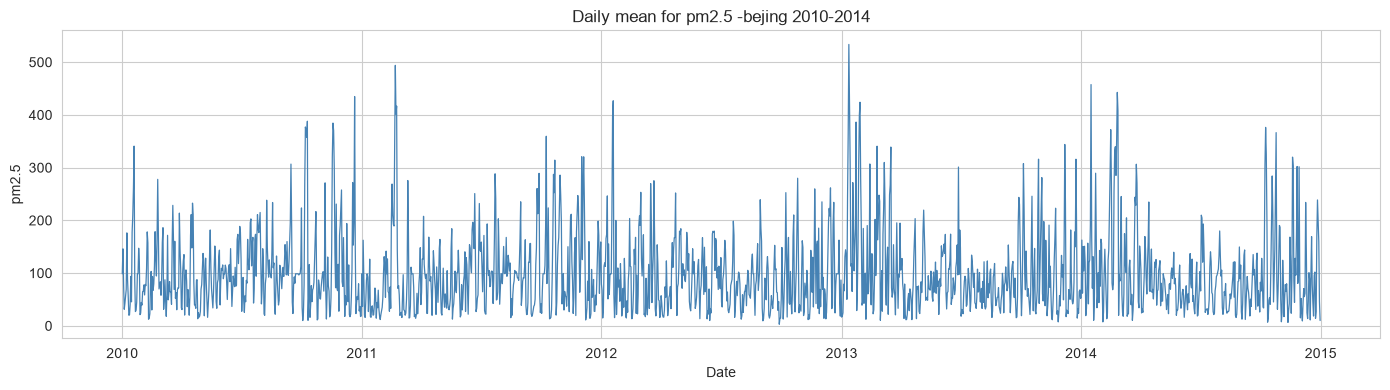

In [8]:
daily = df.set_index('Datetime')['pm2.5'].resample('D').mean()
daily.index
daily.values
plt.figure(figsize=(14,4))
plt.plot(daily.index,daily.values,color='steelblue',linewidth=0.9)
plt.xlabel('Date');plt.ylabel('pm2.5')
plt.title('Daily mean for pm2.5 -bejing 2010-2014')
plt.tight_layout();plt.show()


**Seasonality Analysis**

Text(0.5, 1.0, 'mean PM2.5 by month')

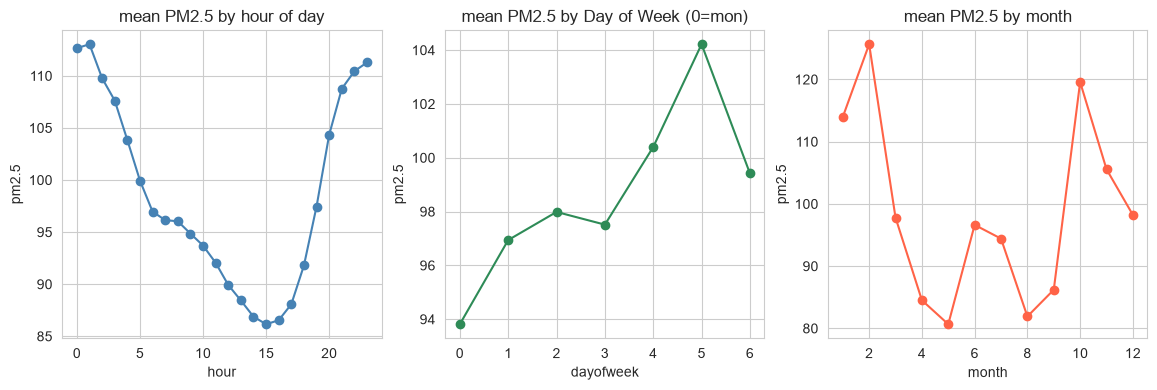

In [9]:
df['dayofweek'] = df['Datetime'].dt.dayofweek
fig,ax = plt.subplots(1,3,figsize=(14,4))
df.groupby('hour')['pm2.5'].mean().plot(ax=ax[0],marker = 'o',color='steelblue')
ax[0].set_ylabel('pm2.5');ax[0].set_title('mean PM2.5 by hour of day')
df.groupby('dayofweek')['pm2.5'].mean().plot(ax=ax[1],marker = 'o',color='seagreen')
ax[1].set_ylabel('pm2.5');ax[1].set_title('mean PM2.5 by Day of Week (0=mon)')
df.groupby('month')['pm2.5'].mean().plot(ax=ax[2],marker = 'o',color='tomato')
ax[2].set_ylabel('pm2.5');ax[2].set_title('mean PM2.5 by month')

In [10]:
df.dtypes

No                    int64
year                  int64
month                 int64
day                   int64
hour                  int64
pm2.5               float64
DEWP                  int64
TEMP                float64
PRES                float64
cbwd                    str
Iws                 float64
Is                    int64
Ir                    int64
Datetime     datetime64[us]
dayofweek             int32
dtype: object

**Correlation Analysis**

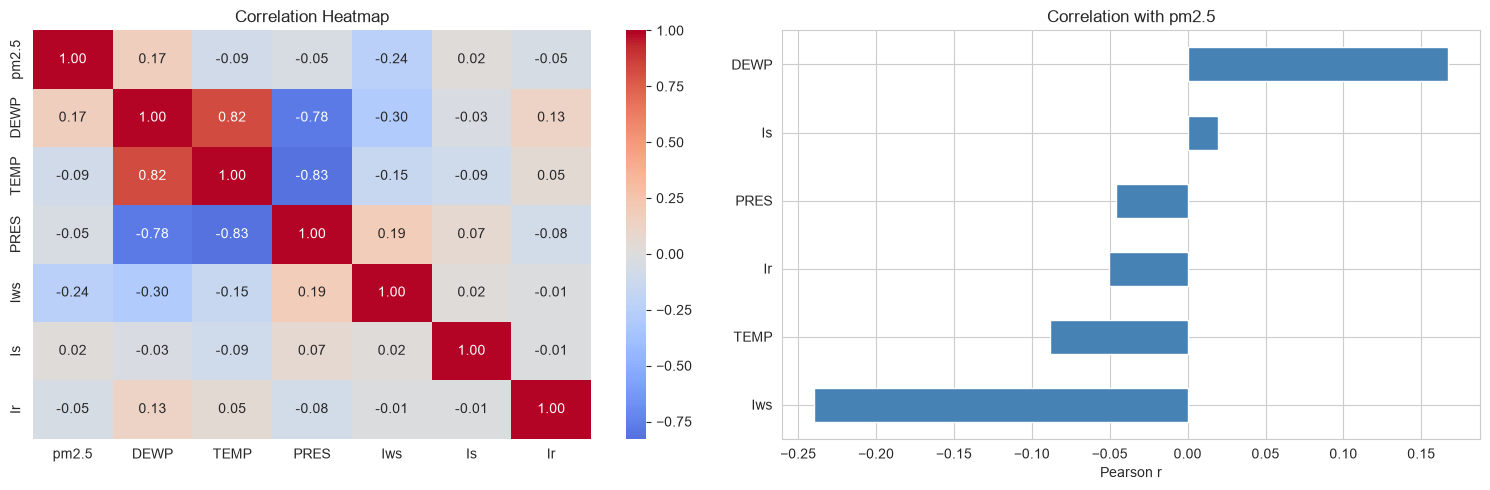

In [11]:
cols =  df.select_dtypes(include='number').columns
num_cols = [ 'pm2.5', 'DEWP', 'TEMP', 'PRES','Iws', 'Is', 'Ir']
corr = df[num_cols].corr()
fig,ax = plt.subplots(1,2,figsize=(15,5))
sns.heatmap(corr,annot=True,ax=ax[0],cmap='coolwarm',fmt='.2f',center=0)
ax[0].set_title('Correlation Heatmap')
corr['pm2.5'].drop('pm2.5').sort_values().plot(kind='barh',ax=ax[1],color='steelblue')
ax[1].set_title('Correlation with pm2.5');ax[1].set_xlabel('Pearson r')
plt.tight_layout();plt.show()

**Wind Direction vs PM2.5**

       mean  count
cbwd              
NE     90.6   4997
NW     71.5  14150
SE    110.2  15290
cv    124.9   9387


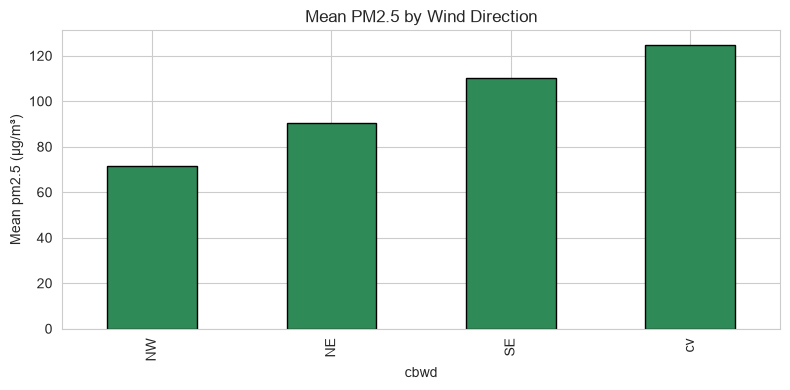

In [12]:
wind_means = df.groupby('cbwd')['pm2.5'].agg(['mean', 'count']).round(1)
print(wind_means)

plt.figure(figsize=(8, 4))
df.groupby('cbwd')['pm2.5'].mean().sort_values().plot(kind='bar', color='seagreen', edgecolor='black')
plt.ylabel('Mean pm2.5 (µg/m³)'); plt.title('Mean PM2.5 by Wind Direction')
plt.tight_layout(); plt.show()

**Sample Week**

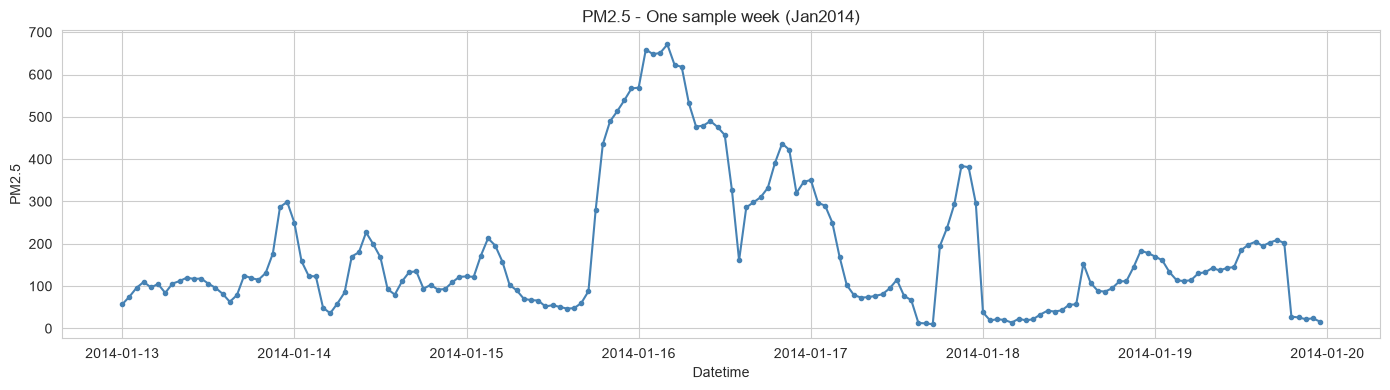

In [13]:
sample_week = df[(df['Datetime']>='2014-01-13') & (df['Datetime']<'2014-01-20')]
plt.figure(figsize=(14,4))
plt.plot(sample_week['Datetime'],sample_week['pm2.5'],marker='.',color='steelblue')
plt.title('PM2.5 - One sample week (Jan2014)')
plt.xlabel('Datetime');plt.ylabel('PM2.5')
plt.tight_layout();plt.show()
